# 🔍 Feature Importance Analysis

Objectif : identifier quelles dimensions des embeddings créent les biais de genre dans le RF.

In [1]:
# Cellule 1: Setup
import os, json, pickle, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Répertoire de travail = experiments/
if os.path.basename(os.getcwd()) != 'experiments':
    if (Path(os.getcwd()) / 'experiments').exists():
        os.chdir(Path(os.getcwd()) / 'experiments')
# Ajouter utils/ au path Python
sys.path.insert(0, str(Path(os.getcwd()).parent / 'utils'))
print(f'📁 Répertoire: {os.getcwd()}')

RESULTS = Path('../results/phase3')
FIGS    = RESULTS / 'figures'
RESULTS.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from scipy.stats import pointbiserialr
from fairness_metrics import compute_fairness_metrics
print('✅ Imports OK')


📁 Répertoire: /Users/antoinedalle/Desktop/Period_3/Fair_AI/Projet/NLP_fairness_project/experiments
✅ Imports OK


In [2]:
# Cellule 2: Données + embeddings
with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

def load_jsonl(p):
    data = []
    with open(p, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip(): data.append(json.loads(line))
    return data

df_train = pd.DataFrame(load_jsonl('medical_bios_data/train.jsonl'))
df_test  = pd.DataFrame(load_jsonl('medical_bios_data/test.jsonl'))
y_train  = le.transform(df_train['title'])
y_test   = le.transform(df_test['title'])
genders  = df_test['gender'].values

# Charger embeddings du meilleur modèle
try:
    with open('../results/phase2/best_embedding_model.json') as f:
        best_info = json.load(f)
    model_id = best_info['model_id']
    print(f'📦 Embeddings: {best_info["label"]}')
except FileNotFoundError:
    model_id = 'distilroberta-base'
    print(f'⚠️  Utilisation de {model_id} par défaut')

safe = model_id.replace('/', '_')
CACHE = Path('embedding_cache')
emb_train = np.load(list(CACHE.glob(f'{safe}_{len(df_train)}*.npy'))[0])
emb_test  = np.load(list(CACHE.glob(f'{safe}_{len(df_test)}*.npy'))[0])
print(f'✅ Embeddings — train: {emb_train.shape}, test: {emb_test.shape}')


📦 Embeddings: DistilRoBERTa
✅ Embeddings — train: (8000, 768), test: (1000, 768)


In [3]:
# Cellule 3: Charger / entraîner RF
# Charger ou entraîner le meilleur RF sur embeddings
RF_PATH = Path('models/best_rf_embeddings.pkl')

if RF_PATH.exists():
    with open(RF_PATH, 'rb') as f:
        rf = pickle.load(f)
    print('📦 RF chargé depuis cache')
else:
    from sklearn.ensemble import RandomForestClassifier
    try:
        with open('../results/phase2/best_rf_params.json') as f:
            p = json.load(f)
    except FileNotFoundError:
        p = {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 2}
    rf = RandomForestClassifier(
        n_estimators=p['n_estimators'],
        max_depth=p['max_depth'],
        min_samples_split=p['min_samples_split'],
        random_state=42, n_jobs=-1
    )
    print('🔄 Entraînement RF...')
    rf.fit(emb_train, y_train)
    with open(RF_PATH, 'wb') as f:
        pickle.dump(rf, f)
    print(f'✅ RF entraîné et sauvegardé → {RF_PATH}')

y_pred  = rf.predict(emb_test)
y_proba = rf.predict_proba(emb_test)
print(f'🎯 Accuracy: {(y_pred == y_test).mean():.4f}')


🔄 Entraînement RF...
✅ RF entraîné et sauvegardé → models/best_rf_embeddings.pkl
🎯 Accuracy: 0.8990


## 📊 Top Features par Importance Gini

📊 Top 50 dimensions sur 768 total
  Variance expliquée par top 50: 0.354 (35.4%)


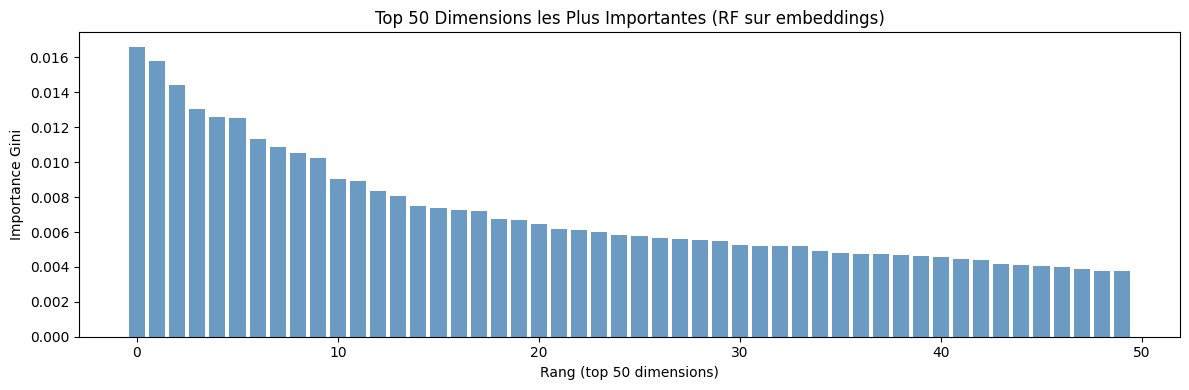

In [4]:
# Cellule 4: Importance Gini — top 50 dimensions
TOP_N = 50
importances = rf.feature_importances_
top_idx = np.argsort(importances)[::-1][:TOP_N]
top_imp = importances[top_idx]

print(f'📊 Top {TOP_N} dimensions sur {len(importances)} total')
print(f'  Variance expliquée par top {TOP_N}: {top_imp.sum():.3f} ({top_imp.sum()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(TOP_N), top_imp, color='steelblue', alpha=0.8)
ax.set_xlabel(f'Rang (top {TOP_N} dimensions)')
ax.set_ylabel('Importance Gini')
ax.set_title(f'Top {TOP_N} Dimensions les Plus Importantes (RF sur embeddings)')
plt.tight_layout()
plt.savefig(FIGS / 'feature_importance_top50.png', dpi=150, bbox_inches='tight')
plt.show()


## 🧬 Corrélation Dimensions × Genre

In [5]:
# Cellule 5: Corrélation point-bisériale dimension ↔ genre
# (genre binaire Male=1 / Female=0)
gender_binary = (genders == 'Male').astype(int)

correlations = []
for dim in top_idx:
    r, p = pointbiserialr(gender_binary, emb_test[:, dim])
    correlations.append({'dim': dim, 'r': r, 'p_value': p, 'importance': importances[dim]})

corr_df = pd.DataFrame(correlations).sort_values('r', key=abs, ascending=False)
print('🔗 Top 15 dimensions les plus corrélées avec le genre:')
print(corr_df.head(15)[['dim','r','p_value','importance']].round(4).to_string(index=False))

# Seuil de significativité
sig = corr_df[corr_df['p_value'] < 0.05]
print(f'\n⚠️  {len(sig)}/{TOP_N} dimensions significativement corrélées avec le genre (p<0.05)')


🔗 Top 15 dimensions les plus corrélées avec le genre:
 dim       r  p_value  importance
 197  0.7749      0.0      0.0042
 153 -0.7450      0.0      0.0060
 755 -0.7444      0.0      0.0041
 500  0.6805      0.0      0.0102
 370 -0.6745      0.0      0.0081
 387 -0.5295      0.0      0.0109
 185 -0.5186      0.0      0.0039
  75  0.5011      0.0      0.0144
 683  0.4962      0.0      0.0075
 482  0.4928      0.0      0.0055
 187  0.4903      0.0      0.0061
 619  0.4736      0.0      0.0056
 621  0.4643      0.0      0.0062
 641 -0.3907      0.0      0.0038
 522  0.3544      0.0      0.0044

⚠️  44/50 dimensions significativement corrélées avec le genre (p<0.05)


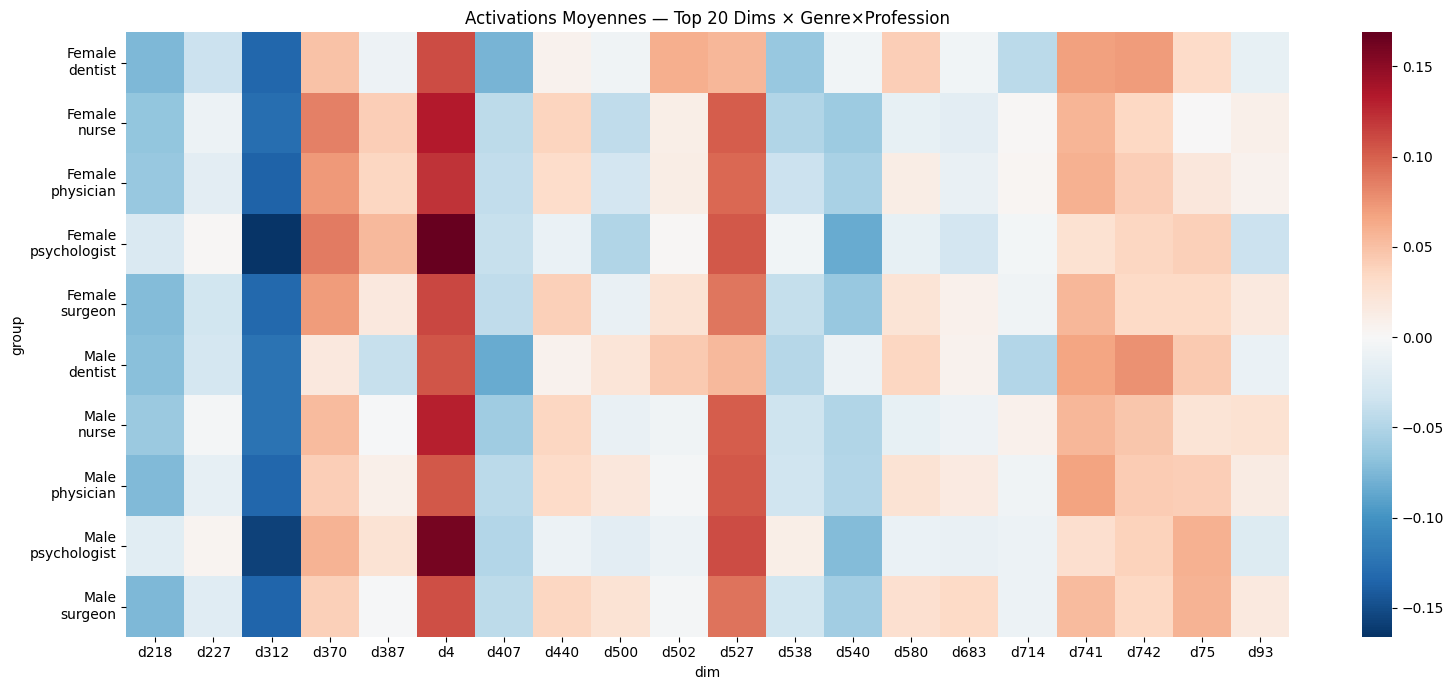

In [6]:
# Cellule 6: Heatmap — activations moyennes par genre et profession
# Pour les 20 dims les plus importantes
TOP_VIZ = 20
viz_dims = top_idx[:TOP_VIZ]

rows = []
for g in ['Female', 'Male']:
    for cid, prof in enumerate(le.classes_):
        mask = (genders == g) & (y_test == cid)
        if mask.sum() > 0:
            mean_act = emb_test[mask][:, viz_dims].mean(axis=0)
            for i, dim in enumerate(viz_dims):
                rows.append({'group': f'{g}\n{prof}', 'dim': f'd{dim}', 'mean': mean_act[i]})

act_df = pd.DataFrame(rows)
pivot  = act_df.pivot(index='group', columns='dim', values='mean')

plt.figure(figsize=(16, 7))
sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=False,
            xticklabels=True, yticklabels=True)
plt.title(f'Activations Moyennes — Top {TOP_VIZ} Dims × Genre×Profession')
plt.tight_layout()
plt.savefig(FIGS / 'activation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


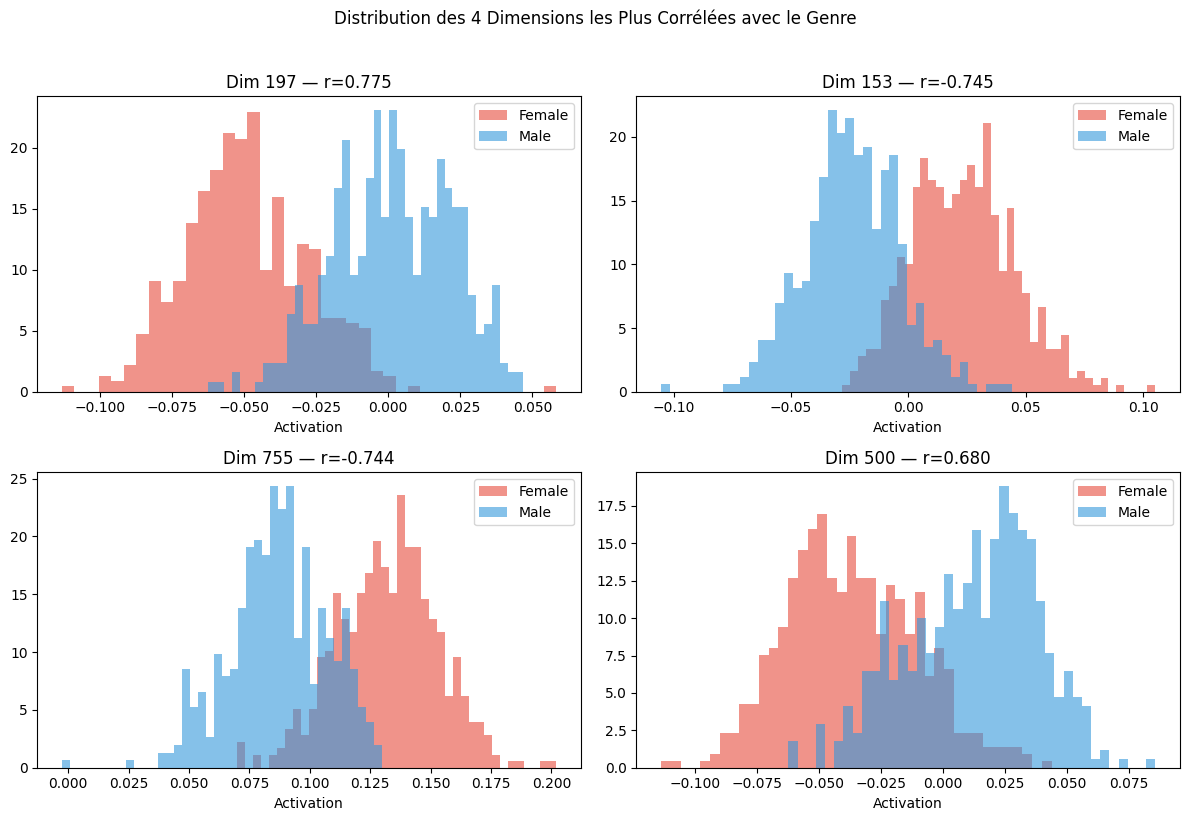

In [7]:
# Cellule 7: Distributions des dims les plus biaisées
# Afficher les 4 dims les plus corrélées avec le genre
biased_dims = corr_df.head(4)['dim'].values

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, dim in enumerate(biased_dims):
    ax = axes[i]
    for g, color in [('Female', '#e74c3c'), ('Male', '#3498db')]:
        mask = genders == g
        ax.hist(emb_test[mask, dim], bins=40, alpha=0.6, label=g, color=color, density=True)
    r = corr_df[corr_df['dim']==dim]['r'].values[0]
    ax.set_title(f'Dim {dim} — r={r:.3f}')
    ax.set_xlabel('Activation')
    ax.legend()

plt.suptitle('Distribution des 4 Dimensions les Plus Corrélées avec le Genre', y=1.02)
plt.tight_layout()
plt.savefig(FIGS / 'biased_dims_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
# Cellule 8: Sauvegarder
corr_df.to_csv(RESULTS / 'feature_importance_gender_correlation.csv', index=False)
pd.DataFrame({'dim': top_idx, 'importance': top_imp}).to_csv(
    RESULTS / 'top50_feature_importances.csv', index=False)

print('💾 feature_importance_gender_correlation.csv')
print('💾 top50_feature_importances.csv')
print(f'\n🔎 RÉSUMÉ:')
print(f'  Dimensions analysées : {len(importances)}')
print(f'  Top 50 couvrent     : {top_imp.sum()*100:.1f}% de l importance')
print(f'  Dims biaisées (p<0.05): {len(sig)}/{TOP_N}')
print(f'  Dim la plus corrélée  : {corr_df.iloc[0]["dim"]} (r={corr_df.iloc[0]["r"]:.3f})')


💾 feature_importance_gender_correlation.csv
💾 top50_feature_importances.csv

🔎 RÉSUMÉ:
  Dimensions analysées : 768
  Top 50 couvrent     : 35.4% de l importance
  Dims biaisées (p<0.05): 44/50
  Dim la plus corrélée  : 197.0 (r=0.775)
